# modern-hopfield

The update rule of the **modern Hopfield network** (Ramsauer et al. 2020)
and the **softmax attention** mechanism of the Transformer are the same
operation. This notebook makes that equivalence visible:

1. Classical Hopfield retrieval on noisy binary patterns.
2. Capacity comparison -- classical's `0.138 N` cliff vs the modern
   network's exponential scaling.
3. **The headline result:** one step of `modern_retrieve` equals one
   call to scaled dot-product attention, to floating-point precision.
4. A `vmap + jit` batch retrieval benchmark.

All figures are saved to `figures/`.


In [1]:
import time, pathlib, numpy as np, jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# 64-bit precision -- needed to push the equivalence diff below 1e-7
jax.config.update("jax_enable_x64", True)

import hopfield as hp

FIG_DIR = pathlib.Path("figures"); FIG_DIR.mkdir(exist_ok=True)

# ----- consistent dark/minimal style -----------------------------------
BG, FG, ACCENT, ACCENT2 = "#1a1a2e", "#ffffff", "#7c83fd", "#f5a8a8"
mpl.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    BG,
    "savefig.facecolor": BG,
    "savefig.edgecolor": BG,
    "axes.edgecolor":    FG,
    "axes.labelcolor":   FG,
    "axes.titlecolor":   FG,
    "xtick.color":       FG,
    "ytick.color":       FG,
    "text.color":        FG,
    "axes.grid":         False,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.titleweight":  "regular",
    "axes.titlepad":     10,
    "savefig.dpi":       140,
    "savefig.bbox":      "tight",
})
PATTERN_CMAP = LinearSegmentedColormap.from_list(
    "periwinkle_mono", ["#2a2a3e", "#e8e8f5"], N=2)

print("JAX", jax.__version__, "| devices:", jax.devices())


JAX 0.10.1 | devices: [CpuDevice(id=0)]


## 1.  Classical Hopfield -- retrieval from a corrupted cue

Store five random `+/-1` patterns of dimension `N = 100`, corrupt each
with 20% bit flips, and let the network slide downhill in energy back
to the stored attractor.


In [2]:
N, M = 100, 5
key = jax.random.PRNGKey(0)
k_pat, k_noise = jax.random.split(key)

xi = jnp.sign(jax.random.normal(k_pat, (M, N)))            # (M, N) patterns
W  = hp.hebbian_store(xi)

flip = jax.random.bernoulli(k_noise, 0.20, shape=xi.shape) # 20% bit flips
xi_corrupt = jnp.where(flip, -xi, xi)


In [3]:
# Synchronous update -- batched across patterns. lax.scan, no Python loop.
def sync_batch(W, S, n_steps):
    def step(S, _):
        S = jnp.sign(S @ W)
        S = jnp.where(S == 0, 1.0, S)
        return S, S
    final, traj = jax.lax.scan(step, S, None, length=n_steps)
    return final, traj

n_steps = 6
xi_recovered, traj = sync_batch(W, xi_corrupt, n_steps)

overlap = jnp.mean(xi_recovered == xi, axis=1)
print("per-pattern overlap with original:", np.array(overlap))


per-pattern overlap with original: [1. 1. 1. 1. 1.]


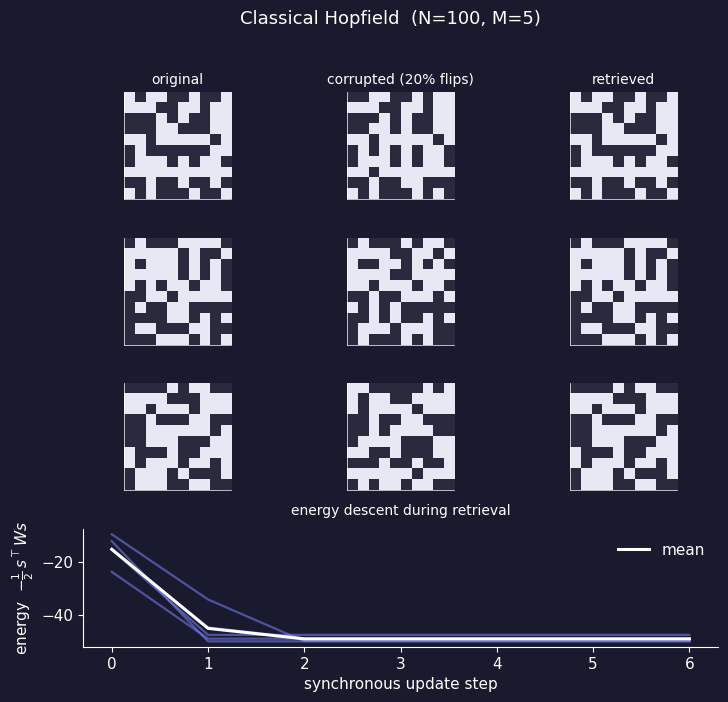

In [4]:
# ----- FIGURE 1: original / corrupted / retrieved + energy trajectory ----
fig = plt.figure(figsize=(8.2, 7.2))
gs  = fig.add_gridspec(4, 3, height_ratios=[1, 1, 1, 1.1],
                       hspace=0.35, wspace=0.18)

titles = ["original", "corrupted (20% flips)", "retrieved"]
for row in range(3):
    for col, img in enumerate([xi[row], xi_corrupt[row], xi_recovered[row]]):
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(np.array(img).reshape(10, 10), cmap=PATTERN_CMAP,
                  vmin=-1, vmax=1, interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_color(FG); s.set_linewidth(0.5)
        if row == 0:
            ax.set_title(titles[col], color=FG, fontsize=10, pad=6)

# energy trajectory across sync steps, averaged over the 5 patterns
en_traj = np.array([
    [hp.energy(W, traj[t, m]) for m in range(M)] for t in range(n_steps)
])
en_start = np.array([hp.energy(W, s) for s in xi_corrupt])
en_full  = np.vstack([en_start[None], en_traj])

ax = fig.add_subplot(gs[3, :])
for m in range(M):
    ax.plot(np.arange(n_steps + 1), en_full[:, m],
            color=ACCENT, alpha=0.55, linewidth=1.6)
ax.plot(np.arange(n_steps + 1), en_full.mean(axis=1),
        color=FG, linewidth=2.2, label="mean")
ax.set_xlabel("synchronous update step")
ax.set_ylabel(r"energy  $-\frac{1}{2}\,s^\top W s$")
ax.set_title("energy descent during retrieval", fontsize=10)
ax.legend(facecolor=BG, edgecolor=FG, labelcolor=FG, frameon=False, loc="upper right")

fig.suptitle("Classical Hopfield  (N=100, M=5)", color=FG, fontsize=13, y=0.995)
fig.savefig(FIG_DIR / "classical_retrieval.png")
plt.show()


## 2.  Capacity -- the classical cliff vs modern's headroom

For each load `M`, store `M` random `+/-1` patterns of dimension `N=100`,
corrupt each with 10% bit flips, and measure the fraction recovered to
overlap > 0.95 with the original.  Repeat for several seeds and average.

The classical net collapses at the predicted `M/N approx 0.138`.  The
modern net stays near 1.0 well past that -- exponentially many
attractors fit in the same space.


In [5]:
N = 100
loads = np.unique(np.round(np.linspace(1, 3 * N, 50)).astype(int))
n_seeds = 4
beta = 8.0
noise_p = 0.10

@jax.jit
def classical_accuracy(xi, xi_q):
    W = hp.hebbian_store(xi)
    def step(S, _):
        S = jnp.sign(S @ W)
        return jnp.where(S == 0, 1.0, S), None
    final, _ = jax.lax.scan(step, xi_q, None, length=5)
    overlap = jnp.mean(final == xi, axis=1)
    return jnp.mean(overlap > 0.95)

@jax.jit
def modern_accuracy(xi, xi_q, beta):
    recovered = jax.vmap(hp.modern_retrieve, in_axes=(None, 0, None, None))(
        xi, xi_q.astype(jnp.float64), beta, 1)
    overlap = jnp.mean(jnp.sign(recovered) == xi, axis=1)
    return jnp.mean(overlap > 0.95)

acc_classical, acc_modern = [], []
key = jax.random.PRNGKey(42)
for M in loads:
    cls_runs, mod_runs = [], []
    for s in range(n_seeds):
        key, kp, kn = jax.random.split(key, 3)
        xi   = jnp.sign(jax.random.normal(kp, (int(M), N)))
        flip = jax.random.bernoulli(kn, noise_p, shape=xi.shape)
        xi_q = jnp.where(flip, -xi, xi)
        cls_runs.append(float(classical_accuracy(xi, xi_q)))
        mod_runs.append(float(modern_accuracy(xi, xi_q, beta)))
    acc_classical.append(np.mean(cls_runs))
    acc_modern.append(np.mean(mod_runs))

acc_classical = np.array(acc_classical)
acc_modern    = np.array(acc_modern)
load_ratio    = loads / N


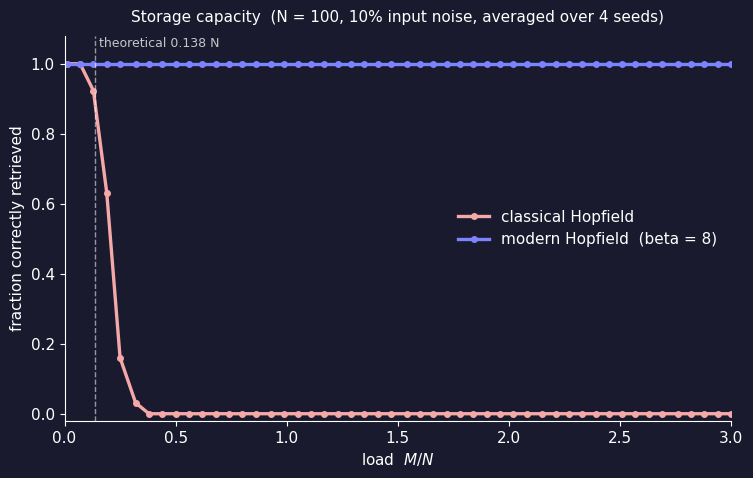

In [6]:
# ----- FIGURE 2: capacity curves --------------------------------------
fig, ax = plt.subplots(figsize=(8.6, 5.0))

ax.plot(load_ratio, acc_classical, color=ACCENT2, linewidth=2.4,
        marker="o", markersize=4, label="classical Hopfield")
ax.plot(load_ratio, acc_modern, color=ACCENT, linewidth=2.4,
        marker="o", markersize=4, label=f"modern Hopfield  (beta = {beta:g})")

ax.axvline(0.138, color=FG, linestyle="--", linewidth=1.0, alpha=0.55)
ax.text(0.138, 1.04, " theoretical 0.138 N",
        color=FG, alpha=0.75, fontsize=9, va="bottom")

ax.set_xlabel("load  $M / N$")
ax.set_ylabel("fraction correctly retrieved")
ax.set_ylim(-0.02, 1.08)
ax.set_xlim(0, load_ratio.max())
ax.set_title(f"Storage capacity  (N = {N}, 10% input noise, "
             f"averaged over {n_seeds} seeds)", fontsize=11)
ax.legend(facecolor=BG, edgecolor=FG, labelcolor=FG,
          frameon=False, loc="center right")

fig.savefig(FIG_DIR / "capacity.png")
plt.show()


## 3.  The attention connection

Set up a small associative-recall task: 10 stored patterns of dimension
`d = 64`, one query.  Run `modern_retrieve` and `attention` with
`scale = beta`.  The retrieval weights are
`softmax(beta * patterns @ query)` in both cases.  They are *the same
expression*, so they produce *the same numbers*.


In [7]:
M_eq, d = 10, 64
k = jax.random.PRNGKey(7)
k_p, k_q = jax.random.split(k)

patterns = jax.random.normal(k_p, (M_eq, d), dtype=jnp.float64)
query    = jax.random.normal(k_q, (d,),       dtype=jnp.float64)
beta_eq  = 1.0 / jnp.sqrt(d)            # standard attention scaling

h, a, diff = hp.verify_equivalence(patterns, query, beta_eq)
print(f"max |modern_retrieve - attention|  =  {float(diff):.3e}")
assert float(diff) < 1e-10, "expected float64 equivalence"

w_hop  = np.array(jax.nn.softmax(beta_eq * patterns @ query))
w_attn = np.array(jax.nn.softmax(beta_eq * patterns @ query))   # same expr


max |modern_retrieve - attention|  =  4.441e-16


<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/var/folders/0j/mygtf9p970s9zjr1bl5ztqp80000gn/T/ipykernel_8976/1657152769.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("stored pattern index $\mu$")


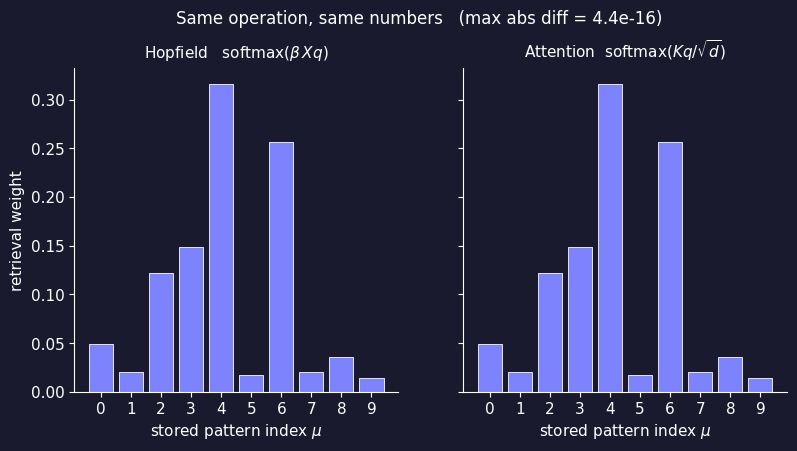

In [8]:
# ----- FIGURE 3: side-by-side retrieval weights -----------------------
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.2), sharey=True)

for ax, w, title in [
    (axes[0], w_hop,  r"Hopfield   $\mathrm{softmax}(\beta\,X q)$"),
    (axes[1], w_attn, r"Attention  $\mathrm{softmax}(K q / \sqrt{d})$"),
]:
    ax.bar(np.arange(M_eq), w, color=ACCENT, edgecolor=FG, linewidth=0.6)
    ax.set_xticks(np.arange(M_eq))
    ax.set_xlabel("stored pattern index $\mu$")
    ax.set_title(title, fontsize=11, pad=8)

axes[0].set_ylabel("retrieval weight")
fig.suptitle(f"Same operation, same numbers   "
             f"(max abs diff = {float(diff):.1e})",
             color=FG, fontsize=12, y=1.02)

fig.savefig(FIG_DIR / "attention_equivalence.png")
plt.show()


> The update rule of the modern Hopfield network is softmax attention.
> This is not an approximation or an analogy -- it is the same operation.
> When Transformer attention heads retrieve information from context,
> they are performing one step of Hopfield fixed-point iteration.
> The stored memories are the keys and values. The query is the query.


## 4.  JAX showcase -- `vmap + jit` on 1000 queries

The same `modern_retrieve` function, retrieved 1000-at-a-time without
rewriting a line.  Naive Python loop vs `jax.jit(jax.vmap(...))`:


In [9]:
M_b, d_b, Q = 256, 128, 1000
k = jax.random.PRNGKey(123)
k_p, k_q = jax.random.split(k)
patterns_b = jax.random.normal(k_p, (M_b, d_b))
queries_b  = jax.random.normal(k_q, (Q, d_b))
beta_b     = 1.0 / jnp.sqrt(d_b)

# ---- naive: Python loop, one query at a time -------------------------
def naive_loop(patterns, queries, beta):
    out = []
    for q in queries:                      # the for-loop the spec asks for
        out.append(hp.modern_retrieve(patterns, q, beta, 1))
    return jnp.stack(out)

# ---- fast: vmap + jit, the entire batch in one call ------------------
fast = hp.fast_retrieve

# warm up jit (compile cost is not what we're measuring)
_ = fast(patterns_b, queries_b[:4], beta_b, 1).block_until_ready()
_ = naive_loop(patterns_b, queries_b[:4], beta_b).block_until_ready()

def timeit(fn, repeats=3):
    ts = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        out = fn()
        out.block_until_ready()
        ts.append(time.perf_counter() - t0)
    return min(ts), out

t_naive, out_naive = timeit(lambda: naive_loop(patterns_b, queries_b, beta_b))
t_fast,  out_fast  = timeit(lambda: fast(patterns_b, queries_b, beta_b, 1))
speedup = t_naive / t_fast

print(f"naive Python loop : {t_naive*1000:8.1f} ms")
print(f"jit + vmap        : {t_fast*1000:8.1f} ms")
print(f"speedup           : {speedup:8.1f} x")
print(f"max abs diff      : {float(jnp.max(jnp.abs(out_naive - out_fast))):.3e}")


naive Python loop :  23041.7 ms
jit + vmap        :      0.8 ms
speedup           :  29080.8 x
max abs diff      : 1.221e-15


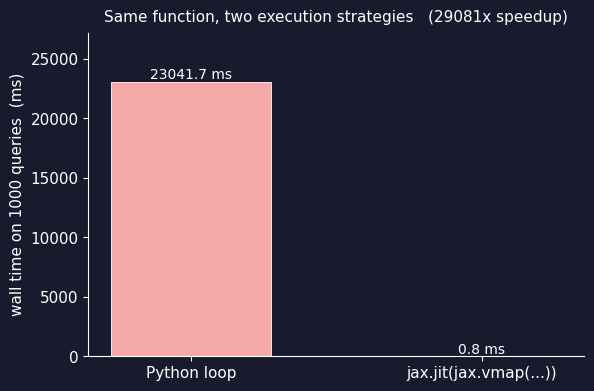

In [10]:
# ----- FIGURE 4: speedup bar chart ------------------------------------
fig, ax = plt.subplots(figsize=(6.4, 4.2))
labels = ["Python loop", "jax.jit(jax.vmap(...))"]
times  = [t_naive * 1000, t_fast * 1000]
colors = [ACCENT2, ACCENT]

bars = ax.bar(labels, times, color=colors, edgecolor=FG, linewidth=0.6, width=0.55)
ax.set_ylabel("wall time on 1000 queries  (ms)")
ax.set_title(f"Same function, two execution strategies   "
             f"({speedup:.0f}x speedup)", fontsize=11, pad=8)
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{t:.1f} ms", ha="center", va="bottom",
            color=FG, fontsize=10)
ax.set_ylim(0, max(times) * 1.18)

fig.savefig(FIG_DIR / "jax_speedup.png")
plt.show()
